# Contents
1. Basics
   - Definitions and examples
   - Connection to quantum state vectors
2. Convex combinations
   - The completely mixed state
   - Probabilistic states
   - Density matrices and the spectral theorem
3. Bloch sphere
4. Multiple systems
   - Product states, correlated states, and entanglement
   - Reduced states and partial trace

# Motivation 
- Density matrices represent a 🔴 **broader class** of quantum states than quantum state vectors. This includes quantum states with uncertainty or randomness. This is useful in modeling noise in quantum computation.
- Density matrices can describe states of 🔴 **isolated parts** of system, such as the state of one system that happens to be entangled with another system that *we wish to ignore*.
- Probabilistic states can be represented by density matrices, allowing quantum and classical information to be described *together* within a 🔴 **single mathematical framework.**

# Definition of density matrices
Suppose that $X$ is a system and $\Sigma$ is its classical state set.

A **density matrix** describing a state of $X$ is matrix with complex number entries whose rows and columns have been placed in correspondence with $\Sigma$.

Typical names for density matrices: $\rho,\sigma, ...$


## Requirements 
1. Density matrices have a unit trace: $\text{Tr}(\rho)=1$
2. Density matrices are a positive semidefinite: $\rho\geq0$


## Trace

Sum of all diagonal entries.

Trace is a linear function:
$$ \text{Tr}(\alpha A+\beta B)=\alpha\text{Tr}(A)+\beta\text{Tr}(B) $$

## Positive semidefinite

This is a property that can be expressed in several different ways, including these:
- There exists a matrix $M$, such that $\rho=M^\dagger M$
- The matrix $\rho$ is Hermitian, meaning that $\rho=\rho^\dagger$, and all of its eigenvalues are nonnegative real numbers.
  - In general, Hermitian matrices can have real number eigenvalues, but it can be negative.
- For every complex vector $\ket{\psi}$ we have $\bra{\psi}\rho\ket{\psi}\geq0$

You can use this characterizations to determine if a given matrix is positive semidefinite.

**Note that the notation $\rho\geq 0$ means that $\rho$ is positive semidefinite - not that each entry of $\rho$ is nonnegative.**

## Examples of positive semidefinite matrices

We can generate an exmaple of a positive semidefinite matrix by first choosing a matrix $M$ arbitrarily and computing $M^\dagger M$.

In [42]:
import numpy as np

M = np.random.rand(3,3) + 1j * np.random.rand(3,3)
p = M.conj().T.dot(M)
print("rho is always positive semidefinite")
print(p)
print()
print("Verify all eigenvalues are positive")
print(f"eigenvalues = {np.linalg.eigvals(p).round(4)}")

rho is always positive semidefinite
[[2.82092097+0.j         1.62468812-0.25032926j 2.5345508 -0.0599271j ]
 [1.62468812+0.25032926j 1.82694561+0.j         1.84149549+0.77681209j]
 [2.5345508 +0.0599271j  1.84149549-0.77681209j 2.91849176+0.j        ]]

Verify all eigenvalues are positive
eigenvalues = [6.7409-0.j 0.788 -0.j 0.0375-0.j]


## Examples of density matrices

In [55]:
ex1 = np.array([
    [1,0],
    [0,0]
])
print("All eigenvalues of ex1 are nonnegative", (np.linalg.eigvals(ex1) >= 0).all())
ex2 = np.array([
    [1/2,1/2],
    [1/2,1/2]
])
print("All eigenvalues of ex2 are nonnegative", (np.linalg.eigvals(ex2) >= 0).all())
ex3 = np.array([
    [3/4,1j/8],
    [-1j/8,1/4]
])
print("All eigenvalues of ex3 are nonnegative", (np.linalg.eigvals(ex3) >= 0).all())
ex4 = np.array([
    [1/2,0],
    [0,1/2]
])
print("All eigenvalues of ex4 are nonnegative", (np.linalg.eigvals(ex4) >= 0).all())

All eigenvalues of ex1 are nonnegative True
All eigenvalues of ex2 are nonnegative True
All eigenvalues of ex3 are nonnegative True
All eigenvalues of ex4 are nonnegative True


We can also **normalize** by taking a positive semidefinite matrix and dividing it by its trace.

In [60]:
new_p = p / (p.diagonal().sum())
print(p)
print("Trace:", new_p.diagonal().sum())
print("All eigenvalues of new_p are nonnegative", (np.linalg.eigvals(new_p) >= 0).all())

[[2.82092097+0.j         1.62468812-0.25032926j 2.5345508 -0.0599271j ]
 [1.62468812+0.25032926j 1.82694561+0.j         1.84149549+0.77681209j]
 [2.5345508 +0.0599271j  1.84149549-0.77681209j 2.91849176+0.j        ]]
Trace: (1+0j)
All eigenvalues of new_p are nonnegative True


# Interpretation
Acknowledge that we are representing the state of a system as a matrix rather than a vector. Although you can always think of matrices as linear mappings, we don't typically associate a direct intuitive meaning to the linear mapping assiciated with a given matrix.

## Intuitive meaning of density matrix entries
For a given density matrix both the rows and the columns correspond to classical states. 
- **Diagonal** entries are the probabilities for each classical state to appear from a standard basis measurement.
- **Off-diagonal** entries describe how the two corresponding classical states are in **quantum superposition**. As well as the "relative phase" between them.

## Connection to state vectors
A quantum state vector $\ket{\psi}$ is a column vector having a Euclidean norm 1.

Here's the density matrix representation of the same state:
$$ \ket{\psi}\bra{\psi} $$

This will always be a positive semifinite matrix.

States that are represented by density matrices of this form are called **pure states**.

## Examples of pure states

In [78]:
ket_0 = np.array([[1],[0]])
ket_1 = np.array([[0],[1]])
ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])
ket_minus = np.array([[1/np.sqrt(2)],[-1/np.sqrt(2)]])
ket_psi = np.array([[(1+2j)/3],[-2/3]])

print(ket_0.dot(ket_0.T))
print("eigvals", np.linalg.eigvals(ket_0.dot(ket_0.T)))
print()
print(ket_1.dot(ket_1.T))
print("eigvals", np.linalg.eigvals(ket_1.dot(ket_1.T)))
print()
print(ket_plus.dot(ket_plus.T))
print("eigvals", np.linalg.eigvals(ket_plus.dot(ket_plus.T)))
print()
print(ket_minus.dot(ket_minus.T))
print("eigvals", np.linalg.eigvals(ket_minus.dot(ket_minus.T)))
print()
print(ket_psi.dot(ket_psi.conj().T))
print("eigvals", np.linalg.eigvals(ket_psi.dot(ket_psi.conj().T)).round(4))

[[1 0]
 [0 0]]
eigvals [1. 0.]

[[0 0]
 [0 1]]
eigvals [0. 1.]

[[0.5 0.5]
 [0.5 0.5]]
eigvals [1. 0.]

[[ 0.5 -0.5]
 [-0.5  0.5]]
eigvals [1. 0.]

[[ 0.55555556+0.j         -0.22222222-0.44444444j]
 [-0.22222222+0.44444444j  0.44444444+0.j        ]]
eigvals [1.+0.j 0.-0.j]


**All pure states have an eigenvalue of 1, then the rest is 0**

In general,
$$ \ket{\psi} = \begin{pmatrix} \alpha_0 \\ \alpha_1 \\ \vdots \\ \alpha_{n-1} \end{pmatrix} \Rightarrow \ket{\psi}\bra{\psi} = \begin{pmatrix} |\alpha|^2 & \alpha_0 \overline{\alpha_1} & \dots & \alpha_0 \overline{\alpha_{n-1}}\\\alpha_1 \overline{\alpha_0} & |\alpha_1|^2 & \dots & \alpha_1 \overline{\alpha_{n-1}}\\ \vdots & \vdots & \ddots & \vdots \\ \alpha_{n-1}\overline{\alpha_0} & \alpha_{n-1}\overline{\alpha_1} & \dots & |\alpha_{n-1}|^2\end{pmatrix}$$

We can also see why the trace is equal to 1.

## Remark
There is no **global phase** degeneracy for density matrices: two quantum states are identical if and only if their density matrix representations are equal. 

Suppose $\ket{\psi}$ and $\ket{\phi}$ are quantum state vectors that differ by a global phase:
$$ \ket{\phi}=e^{i\theta}\ket{\psi} $$

The corresponding density matrices are identical:
$$ \ket{\phi}\bra{\phi} = (e^{i\theta}\ket{\psi})(e^{i\theta}\ket{\psi})^\dagger = e^{i(\theta-\theta)}\ket{\psi}\bra{\psi}=\ket{\psi}\bra{\psi} $$

## Probabilistic selections
**Key property of density matrices** 
- **Convex combinations** of density matrices represent probabilistic selections of quantum states
- In other words, we can average density matrices in a meaningful which is not possible in quantum statevector.

Let $\rho$ and $\sigma$ be density matrices representing quantum states of a quantum system, and suppose we prepare the system in state $\rho$ with probability $p\in[0,1]$ and $\sigma$ with probability $1-p$.

The resulting state is represented by this density matrix:
$$ p\rho + (1-p)\sigma $$

- this is like averaging
- this does not work for quantum statevectors, if you did it will break the rule that statevectors should have Euclidean norm of 1

More generally, let $\rho_0,\dots,\rho_{m-1}$, let $(p_0, \dots, p_{m-1})$ be a probability vector, and suppose we prepare a systme in state $\rho_k$ with probability $p_k$

$$ \sum_{k=0}^{m-1} p_k\rho_k$$

- this is what we mean by convex combination of density matrices
- it is simply **a linear combination where the coefficients simply form a probability vector**

If $\ket{\psi_0},\dots,\ket{\psi_{m-1}}$ are quantums state vectors and we prepare a system in state $\ket{\psi_k}$ with probability $p_k$, then the resulting state is represented by this density matrix:

$$ \sum_{k=0}^{m-1} p_k\ket{\psi_k}\bra{\psi_k} $$

- We call this **Mixed state**

## Example of convex combination
A qubit is prepared in the state $\ket{0}$ with probability 1/2 and in state $\ket{+}$ with probability 1/2.

In [85]:
import numpy as np
ket_0 = np.array([[1],[0]])
ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])

p = 1/2 * ket_0.dot(ket_0.T) + 1/2 * ket_plus.dot(ket_plus.T)
print(p)
print("Trace", p.diagonal().sum())
print("Eigvals", np.linalg.eigvals(p))

[[0.75 0.25]
 [0.25 0.25]]
Trace 1.0
Eigvals [0.85355339 0.14644661]


## Completely mixed state
Suppose we set the state of a qubit to be $\ket{0}$ or $\ket{1}$ randomly, eacch with probability 1/2. Here's the density matrix representation of its state.

In [90]:
import numpy as np
ket_0 = np.array([[1],[0]])
ket_1 = np.array([[0],[1]])

p = 1/2 * ket_0.dot(ket_0.T) + 1/2 * ket_1.dot(ket_1.T)
print(p)
print(np.identity(2)/2)
print("Trace", p.diagonal().sum())
print("Eigvals", np.linalg.eigvals(p))

[[0.5 0. ]
 [0.  0.5]]
[[0.5 0. ]
 [0.  0.5]]
Trace 1.0
Eigvals [0.5 0.5]


The resulting state is $I/2$

This is known as the **completely mixed state** - it represents complete uncertainty about the state of a qubit.

Now suppose that we change the procedure: in place of the states $\ket{0}$ and $\ket{1}$ we'll use the states $\ket{+}$ and $\ket{-}$.

In [94]:
import numpy as np
ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])
ket_minus = np.array([[1/np.sqrt(2)],[-1/np.sqrt(2)]])

p = 1/2 * ket_plus.dot(ket_plus.T) + 1/2 * ket_minus.dot(ket_minus.T)
print(p)
print(np.identity(2)/2)
print("Trace", p.diagonal().sum())
print("Eigvals", np.linalg.eigvals(p))

[[0.5 0. ]
 [0.  0.5]]
[[0.5 0. ]
 [0.  0.5]]
Trace 0.9999999999999998
Eigvals [0.5 0.5]


It's the same state as before, the completely mixed state. **This is a feature, not a bug!** The two procedures can't be distinguished by measuring the qubit.

This is true any other test you might devise. 

In general, density matrices don't describe how the system is prepared. It only tells you what will happen *do things* moving forward (either operations or measurements).

If two density matrices are equal, **they cannot be discriminated.**

## Probabilistic states
Classical states can be represented by density matrices.

## Example of classical density matrix

Density matrices for the classical states of 0 and 1 of a qubit:

$$\ket{0}\bra{0}=\begin{pmatrix}1 & 0 \\ 0 & 0\end{pmatrix}\space
\ket{1}\bra{1}=\begin{pmatrix}0 & 0 \\ 0 & 1\end{pmatrix}$$

In general, if a system has a classical state set $\Sigma$, then each classical state $a\in\Sigma$ is represented by the density matrix $\ket{a}\bra{a}$

Probabilistic states are represented by convex combinations of such density matrices.

Suppose the classical state set of $X$ is $\{0,\dots,n-1\}$.

We can identify the probabilistic state of $X$ represented by the probability vector $(p_0, \dots, p_{n-1})$ with this density matrix:

$$\rho=\sum_{k=0}^{n-1}p_k\ket{k}\bra{k}=\begin{pmatrix}p_0 & 0 & \dots & 0 \\ 0 & p_1 & \ddots & \vdots \\ \vdots & \ddots & \ddots & 0\\ 0 & \dots & 0 & p_{n-1}\end{pmatrix} $$

## Spectral Theorem

**Spectral theorem for positive semidefinite matrices**

Suppose $P$ is an $n\times n$ positive semidefinite matrix.

There exists an orthonormal basis $\{\ket{\psi_0},\dots, \ket{\psi_{n-1}}\}$ of vectors along with **nonnegative real** numbers $\lambda_0, \dots, \lambda_{n-1}$ such that 

$$ P = \sum_{k=0}^{n-1} \lambda_k\ket{\psi_k}\bra{\psi_k} $$

- this is what we call **spectral decomposition** of $P$
- each $\lambda_k$ is necessary to be an eigenvalue of $P$
- each $\psi_k$ is a unit eigenvector of $P$

**Note: unit eigenvector means $||v||=1$ where $Pv = \lambda v$**. More generally, $\lambda_k$ is not always nonnegative. It's just that for positive semidefinite matrix, it is defined that $\lambda_k$ to be nonnegative.

**Implication for density matrices** 

Any $n\times n$ density matrix $\rho$ can be expressed as 

$$ \rho=\sum_{k=0}^{n-1} p_k\ket{\psi_k}\bra{\psi_k} $$

for an orthonormal basis $\{\ket{\psi_0},\dots,\ket{\psi_{n-1}}\}$ and a probability vector $(p_0,\dots,p_{n-1})$

## Example of Spectral Decomposition

Recall the example where a qubit is prepared in the state $\ket{0}$ with probability $1/2$ and $\ket{+}$ with probability $1/2$

In [25]:
import numpy as np
ket_0 = np.array([[1],[0]]) 
ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])

p = 1/2 * ket_0.dot(ket_0.T) + 1/2 * ket_plus.dot(ket_plus.T)
print("Density Matrix:")
print(p)

eig_vals, eig_vectors = np.linalg.eig(p)

print()
print("Eigenvalues - Eigenvectors - Norm of Eigenvectors")
for i in range(len(eig_vals)):
    print(eig_vals[i], '-', eig_vectors[:,i], '-', np.sum(eig_vectors[:,i] ** 2))
print()
print("Sum of eigenvalues:", eig_vals.sum())
print()

spectral = []
for i in range(len(eig_vals)):
    coeff = eig_vals[i] 
    basis = eig_vectors[:,i].reshape(-1,1)
    if i == 0:
        spectral = coeff * basis.dot(basis.T)
    else: 
        spectral += coeff * basis.dot(basis.T)

print("Spectral decomposition of the given density matrix rho")
print(spectral)
print("Spectral decomposition uses the eigenvalues and eigenvectors but end up the same density matrix")

Density Matrix:
[[0.75 0.25]
 [0.25 0.25]]

Eigenvalues - Eigenvectors - Norm of Eigenvectors
0.8535533905932737 - [0.92387953 0.38268343] - 1.0
0.1464466094067262 - [-0.38268343  0.92387953] - 1.0

Sum of eigenvalues: 1.0

Spectral decomposition of the given density matrix rho
[[0.75 0.25]
 [0.25 0.25]]
Spectral decomposition uses the eigenvalues and eigenvectors but end up the same density matrix


**By-hand solution**

$$\left|\rho-\lambda I\right|=0$$

$$\left|\begin{pmatrix}\frac{3}{4}-\lambda & \frac{1}{4} \\ \frac{1}{4} & \frac{1}{4}-\lambda\end{pmatrix}\right| = 0 $$

$$\left(\frac{3}{4}-\lambda\right)\left(\frac{1}{4}-\lambda\right)-\left(\frac{1}{4}\right)\left(\frac{1}{4}\right) = 0 $$

$$\left(\frac{3-4\lambda}{4}\right)\left(\frac{1-4\lambda}{4}\right)-\left(\frac{1}{16}\right) = 0 $$

$$\left(\frac{3-12\lambda-4\lambda+16\lambda^2}{16}\right)-\left(\frac{1}{16}\right) = 0 $$

$$\frac{2-16\lambda+16\lambda^2}{16}= 0 $$

$$\lambda^2-\lambda+\frac{1}{8}= 0 $$

Complete the square
$$\lambda^2-\lambda+\frac{1}{4}= -\frac{1}{8}+\frac{1}{4} $$

$$\left(\lambda-\frac{1}{2}\right)^2= \frac{1}{8} $$

$$\sqrt{\left(\lambda-\frac{1}{2}\right)^2}= \sqrt{\frac{1}{8}} $$

$$\lambda-\frac{1}{2}= \pm\frac{1}{2\sqrt{2}} $$

$$\lambda= \frac{1}{2}\pm\frac{1}{2\sqrt{2}} $$

The eigenvalues are 
$$\lambda_0= \frac{1}{2}+\frac{1}{2\sqrt{2}}, \space \lambda_1 = \frac{1}{2}-\frac{1}{2\sqrt{2}} $$

Get the eigenvector for $\lambda_0= \frac{1}{2}+\frac{1}{2\sqrt{2}} $

$$\begin{pmatrix}\frac{3}{4}-\frac{1}{2}+\frac{1}{2\sqrt{2}} & \frac{1}{4} \\ \frac{1}{4} & \frac{1}{4}-\frac{1}{2}+\frac{1}{2\sqrt{2}}\end{pmatrix}\begin{pmatrix}x_0\\x_1\end{pmatrix} = \begin{pmatrix}0\\0\end{pmatrix} $$

$$\begin{pmatrix}\frac{-2+\sqrt{2}}{4\sqrt{2}} & \frac{1}{4} \\ \frac{1}{4} & \frac{-2-\sqrt{2}}{4\sqrt{2}}\end{pmatrix}\begin{pmatrix}x_0\\x_1\end{pmatrix} = \begin{pmatrix}0\\0\end{pmatrix} $$

$$\frac{-2+\sqrt{2}}{4\sqrt{2}}x_0 + \frac{1}{4}x_1 = 0$$

$$\frac{-2+\sqrt{2}}{4\sqrt{2}}x_0 = -\frac{1}{4}x_1 $$

$$-4\frac{-2+\sqrt{2}}{4\sqrt{2}}x_0 = x_1 $$

$$\frac{2-\sqrt{2}}{\sqrt{2}}x_0 = x_1 $$

Therefore, the eigenvector for $\lambda_0$ is

$$\begin{pmatrix}x_0\\\frac{2-\sqrt{2}}{\sqrt{2}}x_0\end{pmatrix} $$

Then, calculate for the unit eigenvector for $\lambda_0$

$$|x_0|^2 + \left| \frac{2-\sqrt{2}}{\sqrt{2}}x_0 \right|^2 = 1 $$

$$|x_0|^2 + \frac{4-4\sqrt{2}+2}{2}|x_0|^2 = 1 $$

$$(4-2\sqrt{2})|x_0|^2 = 1 $$

$$|x_0|^2 = \frac{1}{4-2\sqrt{2}} $$

$$x_0 = \frac{1}{\sqrt{4-2\sqrt{2}}} $$

Substitute to $\begin{pmatrix}x_0\\\frac{2-\sqrt{2}}{\sqrt{2}}x_0\end{pmatrix} $

$$\begin{pmatrix}\frac{1}{\sqrt{4-2\sqrt{2}}}\\\frac{2-\sqrt{2}}{\sqrt{2}}\frac{1}{\sqrt{4-2\sqrt{2}}}\end{pmatrix} =
\begin{pmatrix}\frac{1}{\sqrt{4-2\sqrt{2}}}\\\frac{2-\sqrt{2}}{\sqrt{8-4\sqrt{2}}}\end{pmatrix} $$

We represent $\ket{\psi_\alpha}=\frac{1}{\sqrt{4-2\sqrt{2}}}\ket{0}+\frac{1}{\sqrt{4-2\sqrt{2}}}\\\frac{2-\sqrt{2}}{\sqrt{8-4\sqrt{2}}}\ket{1}$ and parameterize into $$\ket{\psi_\alpha}=\cos{(\alpha)}\ket{0}+\sin{(\alpha)}\ket{1}$$ 

we get

$$\cos{(\alpha)}=\frac{1}{\sqrt{4-2\sqrt{2}}},  \space\sin{(\alpha)}=\frac{2-\sqrt{2}}{\sqrt{8-4\sqrt{2}}}$$ 

$$\alpha=\cos^{-1}{\frac{1}{\sqrt{4-2\sqrt{2}}}}$$

In [19]:
import numpy as np

alpha = np.arccos(1/np.sqrt(4-2*np.sqrt(2)))
print(alpha)
print("which is approximately equal to")
print("pi/8 =", np.pi/8)

0.3926990816987239
which is approximately equal to
pi/8 = 0.39269908169872414


We get the angle

$$\alpha=\frac{\pi}{8} $$

Therefore $$\ket{\psi_{\frac{\pi}{8}}} = \cos{\left(\frac{\pi}{8}\right)}\ket{0}+\sin{\left(\frac{\pi}{8}\right)}\ket{1}=\begin{pmatrix}\cos{\left(\frac{\pi}{8}\right)}\\\sin{\left(\frac{\pi}{8}\right)}\end{pmatrix}$$

And as a density matrix
$$\ket{\psi_{\frac{\pi}{8}}}\bra{\psi_{\frac{\pi}{8}}} = \left[\cos{\left(\frac{\pi}{8}\right)}\ket{0}+\sin{\left(\frac{\pi}{8}\right)}\ket{1}\right]
\left[\cos{\left(\frac{\pi}{8}\right)}\bra{0}+\sin{\left(\frac{\pi}{8}\right)}\bra{1}\right]=\begin{pmatrix}\cos{\left(\frac{\pi}{8}\right)}\\\sin{\left(\frac{\pi}{8}\right)}\end{pmatrix}\begin{pmatrix}\cos{\left(\frac{\pi}{8}\right)}&\sin{\left(\frac{\pi}{8}\right)}\end{pmatrix}
$$

$$\ket{\psi_{\frac{\pi}{8}}}\bra{\psi_{\frac{\pi}{8}}} = \begin{pmatrix}\cos^2{\left(\frac{\pi}{8}\right)} & \cos{\left(\frac{\pi}{8}\right)}\sin{\left(\frac{\pi}{8}\right)}\\\sin{\left(\frac{\pi}{8}\right)}\cos{\left(\frac{\pi}{8}\right)}&\sin^2{\left(\frac{\pi}{8}\right)}\end{pmatrix}
$$

For the another eigenvector, we can easily compute the orthogonal state by adding $90^\circ$ to $\alpha$
$$\alpha+\frac{\pi}{2} = \frac{\pi}{8}+\frac{\pi}{2}$$

$$\alpha+\frac{\pi}{2} = \frac{\pi}{8}+\frac{4\pi}{8}$$

$$\alpha+\frac{\pi}{2} = \frac{5\pi}{8}$$

Therefore,

$$\ket{\psi_{\frac{5\pi}{8}}}\bra{\psi_{\frac{5\pi}{8}}} = \begin{pmatrix}\cos^2{\left(\frac{5\pi}{8}\right)} & \cos{\left(\frac{5\pi}{8}\right)}\sin{\left(\frac{5\pi}{8}\right)}\\\sin{\left(\frac{5\pi}{8}\right)}\cos{\left(\frac{5\pi}{8}\right)}&\sin^2{\left(\frac{5\pi}{8}\right)}\end{pmatrix}
$$

In [31]:
import numpy as np

print("lambda 0 =", 1/2 + 1/(2*np.sqrt(2)))
print("cos^2(pi/8) =", np.cos(np.pi/8)**2)
print("lambda 1 =", 1/2 - 1/(2*np.sqrt(2)))
print("sin^2(pi/8) =", np.sin(np.pi/8)**2)

lambda 0 = 0.8535533905932737
cos^2(pi/8) = 0.8535533905932737
lambda 1 = 0.14644660940672627
sin^2(pi/8) = 0.14644660940672624


Therefore,

$$\frac{1}{2}\ket{0}\bra{0}+\frac{1}{2}\ket{+}\bra{+} = \cos^2{\left(\frac{\pi}{8}\right)}\ket{\psi_{\frac{\pi}{8}}}\bra{\psi_{\frac{\pi}{8}}} + \sin^2{\left(\frac{\pi}{8}\right)}\ket{\psi_{\frac{5\pi}{8}}}\bra{\psi_{\frac{5\pi}{8}}}$$

With these new orthonormal basis we are bias to one state by 85% and 15% to the other state

## Bloch Sphere using Density Matrices

Up to a **global phase**, every qubit quantum state vector is equivalent to 

$$\ket{\psi}= \cos\left(\frac{\theta}{2}\right)\ket{0}+e^{i\phi}\sin{\left(\frac{\theta}{2}\right)}\ket{1}$$

for $\theta\in[0,\pi]$ and $\phi\in[0,2\pi)$

**Sometimes we have to multiply a global phase to the statevector to match the parameterization**

**Almost uniqueness**
It is "almost" the case that $\theta$ and $\phi$ are "uniquely determined" by whatever quantum statevector we started with. 
There is "always" going to be a unique value of $\theta$ between 0 and $\pi$  that works, and "usually" there's a unique value of $\phi$ that works but there are **2 special cases** that is not true!
- If (1) $\theta=0$ or (2) $\theta=\pi$, then $\phi$ is ***irrelevant***.

Otherwise, if $\theta\in(0,\pi)$, then $\phi$ is ***unique***.

**Pure states as density matrix representation:**

$$\ket{\psi}\bra{\psi} = \begin{pmatrix} \cos^2\left(\frac{\theta}{2}\right) & e^{-i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right)\\
e^{i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right) & \sin^2\left(\frac{\theta}{2}\right)
\end{pmatrix}$$

Like all $2\times 2$ matrices, there's a unique way to express this density matrix as a *linear combination of Pauli matrices*

$$ I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \ket{0}\bra{0} + \ket{1}\bra{1} $$

$$ \sigma_X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \ket{0}\bra{1} + \ket{1}\bra{0} $$

$$ \sigma_Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix} = i(\ket{1}\bra{0} - \ket{0}\bra{1})  $$

$$ \sigma_Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \ket{0}\bra{0} - \ket{1}\bra{1}  $$ 

**The density matrix representation of the pure states using Pauli matrices**

$$ \ket{\psi}\bra{\psi} = \frac{I + \sin(\theta)\cos(\phi)\sigma_X + \sin(\theta)\sin(\phi)\sigma_Y+\cos(\theta)\sigma_Z}{2}$$ 

- divided by 2 because it makes everything works nicely
- this is the ONLY way to get the pure state density matrix that takes the linear combination of Pauli matrices
- Pauli matrices including the identity matrix are a basis for space of all $2\times2$ complex matrices
$ A = aI + b\sigma_X + c\sigma_Y + d\sigma_Z $ where $A$ is arbitrary complex matrix

**Proof of Pauli decomposition**

$$\ket{\psi}\bra{\psi} = \begin{pmatrix} \cos^2\left(\frac{\theta}{2}\right) & e^{-i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right)\\
e^{i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right) & \sin^2\left(\frac{\theta}{2}\right)
\end{pmatrix}$$

$$\ket{\psi}\bra{\psi} = \cos^2\left(\frac{\theta}{2}\right)\ket{0}\bra{0} + e^{-i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right) \ket{0}\bra{1} + e^{i\phi}\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right) \ket{1}\bra{0} + \sin^2\left(\frac{\theta}{2}\right)\ket{1}\bra{1}$$

Use the following trigonometric identities:

$$\cos^2\left(\frac{\theta}{2}\right)=\frac{1+\cos(\theta)}{2} $$


$$\sin^2\left(\frac{\theta}{2}\right)=\frac{1-\cos(\theta)}{2} $$


$$\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{\theta}{2}\right)=\frac{\sin(\theta)}{2} $$

$$ e^{i\phi} = \cos(\phi) + i\sin(\phi) $$

Substitute the trigonometric identities

$$\ket{\psi}\bra{\psi} = \frac{1+\cos(\theta)}{2}\ket{0}\bra{0} + \frac{e^{-i\phi}\sin(\theta)}{2}\ket{0}\bra{1} + \frac{e^{i\phi}\sin(\theta)}{2}\ket{1}\bra{0} + \frac{1-\cos(\theta)}{2}\ket{1}\bra{1}$$

$$\ket{\psi}\bra{\psi} = \frac{1+\cos(\theta)}{2}\ket{0}\bra{0} + \frac{[\cos(\phi)-i\sin(\phi)]\sin(\theta)}{2}\ket{0}\bra{1} + \frac{[\cos(\phi)+i\sin(\phi)]\sin(\theta)}{2}\ket{1}\bra{0} + \frac{1-\cos(\theta)}{2}\ket{1}\bra{1}$$

$$\ket{\psi}\bra{\psi} = \frac{1+\cos(\theta)}{2}\ket{0}\bra{0} + \frac{\cos(\phi)\sin(\theta)-i\sin(\phi)\sin(\theta)}{2}\ket{0}\bra{1} + \frac{\cos(\phi)\sin(\theta)+i\sin(\phi)\sin(\theta)}{2}\ket{1}\bra{0} + \frac{1-\cos(\theta)}{2}\ket{1}\bra{1}$$

$$\ket{\psi}\bra{\psi} = \frac{\ket{0}\bra{0}+\cos(\theta)\ket{0}\bra{0}}{2} + \frac{\cos(\phi)\sin(\theta)\ket{0}\bra{1}-i\sin(\phi)\sin(\theta)\ket{0}\bra{1}}{2} + \frac{\cos(\phi)\sin(\theta)\ket{1}\bra{0}+i\sin(\phi)\sin(\theta)\ket{1}\bra{0}}{2} + \frac{\ket{1}\bra{1}-\cos(\theta)\ket{1}\bra{1}}{2}$$

$$\ket{\psi}\bra{\psi} = \frac{\ket{0}\bra{0}+\cos(\theta)\ket{0}\bra{0}}{2} + \frac{\ket{1}\bra{1}-\cos(\theta)\ket{1}\bra{1}}{2}+ \frac{\cos(\phi)\sin(\theta)\ket{0}\bra{1}-i\sin(\phi)\sin(\theta)\ket{0}\bra{1}}{2} + \frac{\cos(\phi)\sin(\theta)\ket{1}\bra{0}+i\sin(\phi)\sin(\theta)\ket{1}\bra{0}}{2}$$

Factor similar coefficients

$$\ket{\psi}\bra{\psi} = \frac{\ket{0}\bra{0}+\ket{1}\bra{1}+\cos(\theta)(\ket{0}\bra{0}-\ket{1}\bra{1})}{2} + \frac{\cos(\phi)\sin(\theta)\ket{0}\bra{1}-i\sin(\phi)\sin(\theta)\ket{0}\bra{1}}{2} + \frac{\cos(\phi)\sin(\theta)\ket{1}\bra{0}+i\sin(\phi)\sin(\theta)\ket{1}\bra{0}}{2}$$

$$\ket{\psi}\bra{\psi} = \frac{\ket{0}\bra{0}+\ket{1}\bra{1}+\cos(\theta)(\ket{0}\bra{0}-\ket{1}\bra{1})}{2} + \frac{\cos(\phi)\sin(\theta)(\ket{0}\bra{1}+\ket{1}\bra{0})+i\sin(\phi)\sin(\theta)(\ket{1}\bra{0}-\ket{0}\bra{1})}{2}$$

$$\ket{\psi}\bra{\psi} = \frac{\ket{0}\bra{0}+\ket{1}\bra{1}+\cos(\theta)(\ket{0}\bra{0}-\ket{1}\bra{1}) + \cos(\phi)\sin(\theta)(\ket{0}\bra{1}+\ket{1}\bra{0})+i\sin(\phi)\sin(\theta)(\ket{1}\bra{0}-\ket{0}\bra{1})}{2}$$

Substitute the Pauli matrices

$$\ket{\psi}\bra{\psi} = \frac{I+\cos(\theta)\sigma_Z + \cos(\phi)\sin(\theta)\sigma_X+\sin(\phi)\sin(\theta)\sigma_Y}{2}$$

$$ \ket{\psi}\bra{\psi} = \frac{I + \sin(\theta)\cos(\phi)\sigma_X + \sin(\theta)\sin(\phi)\sigma_Y+\cos(\theta)\sigma_Z}{2}$$ 

**Bloch Sphere**

Coordinates = $(x,y,z) = (\sin(\theta)\cos(\phi) ,\space \sin(\theta)\sin(\phi) ,\space \cos(\theta))$


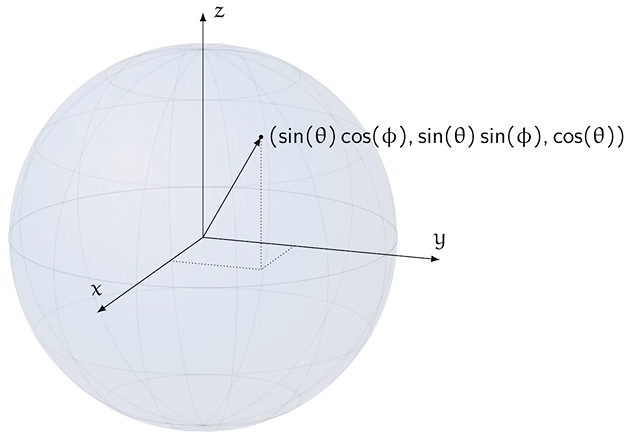

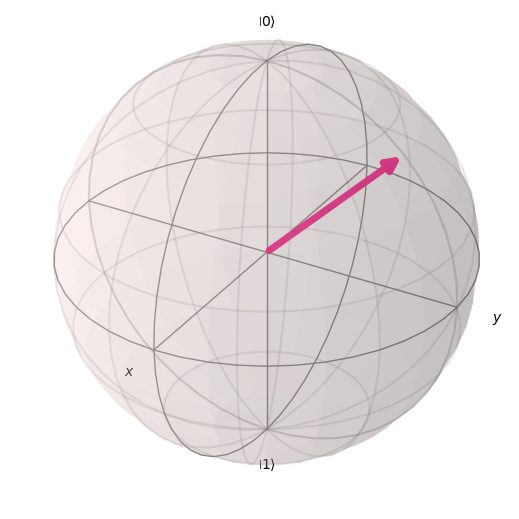

In [12]:
from qiskit.visualization import plot_bloch_vector
import numpy as np

# theta is [0, pi]
# phi is [0, 2pi)
theta = 1/4 * np.pi
phi = np.pi/2

x = np.sin(theta)*np.cos(phi)
y = np.sin(theta)*np.sin(phi)
z = np.cos(theta)
plot_bloch_vector([x,y,z])

**Note: There is a perfect one-to-one correspondence. Every pure state of a qubit corresponds to a unique point in the sphere and every point in the sphere represents a unique qubit state up to a global phase.**

Every point in the *surface* of the sphere is a valid quantum state.

## Bloch Ball

The Bloch ball contains all the points of the Bloch sphere **as well as those inside it.**

- Points in the interior of the Bloch ball correspond to qubit states that are not pure. These states are represented using density matrices but not by pure states.
- Convex combinations of points in the Bloch ball correspond to convex combinations of density matrices.

**Completely mixed state**

The completely mixed state is represented by 

$$\frac{I}{2}=\frac{1}{2}\ket{0}\bra{0}+\frac{1}{2}\ket{1}\bra{1}$$

We can also represent this completely mixed state by averaging *any* two orthogonal pure qubit states.

Example.

$$ \frac{I}{2} = \frac{1}{2}\ket{+}\bra{+} + \frac{1}{2}\ket{-}\bra{-} $$

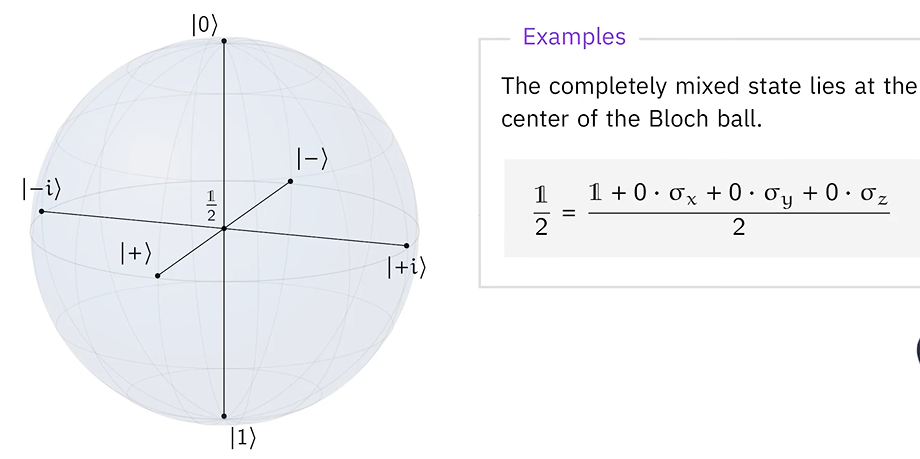

Thinking about the pauli matrix representations makes it clear that *convex combination of Bloch ball points* are just *convex combination of density matrices*. (So we just average the pauli matrix representation of each density matrix)

If we take an average or a weighted average of density matrices and express everything in terms of linear combinations of Pauli matrices, then we are just averaging the corresponding points because everything is linear in those 3 coefficients.

Example.

$$ \frac{1}{2}\ket{0}\bra{0}+ \frac{1}{2}\ket{1}\bra{1}$$

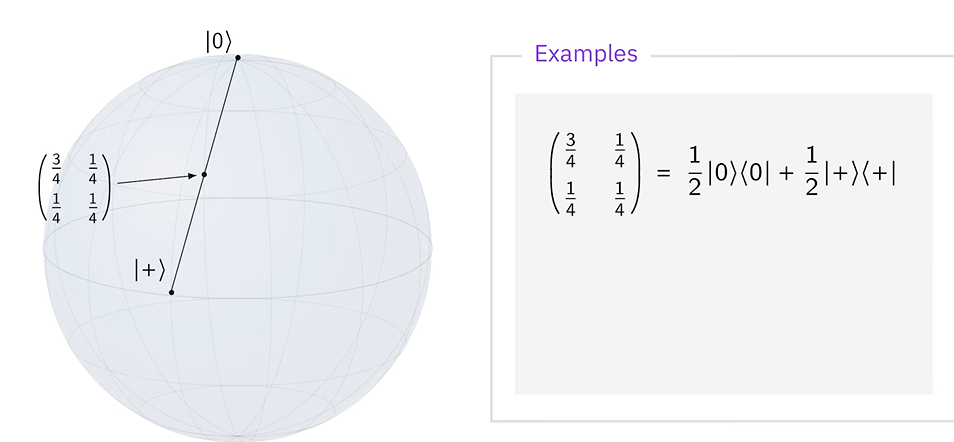

This means that if we draw a line between the point of $\ket{0}$ and $\ket{+}$, the average means the **midpoint** of this line.

By spectral theorem, we can say that 

$$ \frac{1}{2}\ket{0}\bra{0}+ \frac{1}{2}\ket{1}\bra{1} = \cos^2\left(\frac{\pi}{8}\right)\ket{\psi_{\frac{\pi}{8}}}\bra{\psi_{\frac{\pi}{8}}}+\sin^2\left(\frac{\pi}{8}\right)\ket{\psi_{\frac{5\pi}{8}}}\bra{\psi_{\frac{5\pi}{8}}}$$

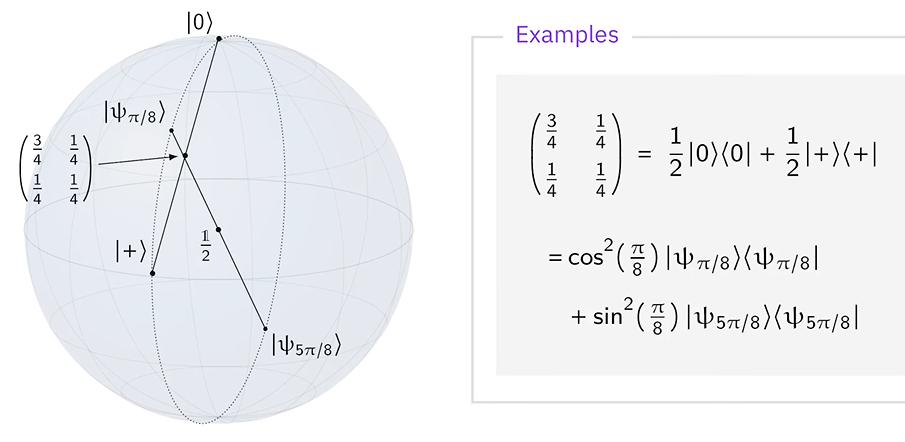

The geometrical intuition is that we draw the line again from the state $\ket{\psi_{\frac{\pi}{8}}}$ going to the other state (in this case, the orthogonal state) $\ket{\psi_{\frac{5\pi}{8}}}$. 

We assume that $\ket{\psi_{\frac{\pi}{8}}}$ coefficient $\cos^2\left(\frac{\pi}{8}\right)\approx0.85$ and that coefficient $\ket{\psi_{\frac{5\pi}{8}}}$ $\sin^2\left(\frac{\pi}{8}\right)\approx0.15$. This means that the point of the mixed state is CLOSER to $\ket{\psi_{\frac{\pi}{8}}}$ that lies between the line. This point is equivalent to the original density matrix.

## Multiple Systems
Density matrices can represent states of multiple systems:
- Multiple systems are viewed as single, compound systems
- The rows and columns of density matrices for multiple systems correspond to *Cartesian products* of the classica state sets of the individual systems

**Example: Bell States**

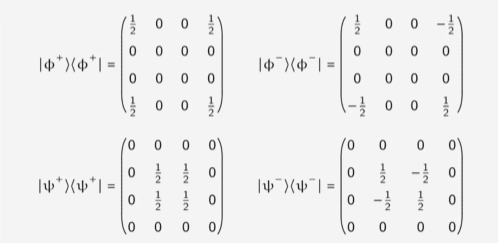

Nothing new on a conceptual level, but there are some *new* things that we can do with density matrices for multiple systems.

## Independence and correlation

- Tensor products of density matrices represent independence between systems


**Product States** 

If $X$ is prepared in the state $\rho$ and $Y$ is independently prepared in the state $\sigma$ then the state $(X,Y)$ is the tensor product $\rho\otimes\sigma$

States of this form are called **product states**

Dnesity matrices that cannot be expressed as product states represent ***correlations*** between systems. Different types of correlations can be considered. 

Same concept in state vectors but in density matrices, there are **different types of correlations** we can consider.

For quantum state vectors, the only correlation we can get is **entanglement**. In other words, correlation and entanglement are synonymous for quantum state vectors but NOT TRUE for density matrices.

## Example: a correlated classical state

A uniform random bit shared between Alice and Bob has this state.

$$\frac{1}{2}\ket{0}\bra{0}\otimes\ket{0}\bra{0} + \frac{1}{2}\ket{1}\bra{1}\otimes\ket{1}\bra{1} = \begin{pmatrix}\frac{1}{2}&0&0&0\\0&0&0&0\\0&0&0&0\\0&0&0&\frac{1}{2}\end{pmatrix} $$

This is NOT an entangled state, but it is a **correlated** state.

## Example: ensembles of quantum states

An **ensemble** describes a *random selection* of quantum state.

The following density matrix represents an ensemble, assuming $(p_0, \dots, p_{m-1})$ is a probability vector and $\rho_0,\dots,\rho_{m-1}$ are density matrices of the same size.

$$\sum_{k=0}^{m-1} p_k\ket{k}\bra{k}\otimes\rho_k$$

The probability vector also tells us the probability that we draw a certain density matrix. If we wanted to, we can just take the **convex combination** of density matrices
$$\sum_{k=0}^{m-1} p_k\rho_k $$

but that will NOT tell us what is the probability of the individual states or what the probabilities where.

The form

$$\sum_{k=0}^{m-1} p_k\ket{k}\bra{k}\otimes\rho_k$$

is a two systems. The first system is a classical state for each of the alternatives and we take the average of $m$ product states. Note that the state of the first sytem is always classical and essentially labels which of the $m$ states we have.

***TLDR: The first system is basically a classical label register for the second system.***

## Example: separable states

Convex combinations of product states represent calssical correlations among quantum states.

$$\sum_{k=0}^{m-1}p_k\rho_k\otimes\sigma_k $$

One way to think is that we will have a probabilistic selection for number $k$ and then independently prepare two systems in a quantum state that can depend on this number $k$.

States that can be written like this are **separable**; if you cannot separate them, then they are **entangled**. 

## Reduced states for an e-bit
One thing we can do with density matrices is to **describe states of isolated parts of systems even when they're correlated and possibly entangled** with other systems. Something we cannot do with state vectors. This is what we call **reduced state**.

Example. Alice and Bob share an e-bit such that $(A,B)$ system is in the $\ket{\phi^+}$ state:

$$\ket{\phi^+}=\frac{1}{\sqrt{2}}\ket{00}+\frac{1}{\sqrt{2}}\ket{11} $$

**Important Question: What is the state of Alice's qubit $A$ in isolation?**

We CANNOT describe the state of $A$ with quantum state vector because, as we'll see, it is *NOT in a pure state*.

But every system has a state at any given moment that can be described by density matrix whether it is entangled with another system or not.

**To answer the question: imagine Bob traveled with his qubit lightyears away from Alice, and then performed standard basis measurement with his qubit**

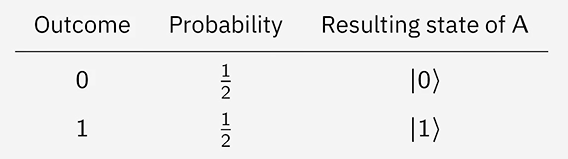

This means, there is half-half probability for $A$. **This is the answer to the question! System $A$ in isolation is in completely mixed state:**

$$ \frac{I}{2}=\frac{1}{2}\ket{0}\bra{0}+\frac{1}{2}\ket{1}\bra{1} $$

You can argue that this is because Bob measured his qubit. But again Bob is light years away!

This does not mean faster than light communication. Regardless, Alice qubit is in completely mixed state. (This is just to explain in intuitive terms)

## Reduced states in general

Suppose we have a pair of systems $(A,B)$ in a pure state $\ket{\psi}$.

We are going to **focus on reduced state of $A$**, and to do this, we think of the classical states of $B$.

Let $\Gamma$ be the classical state set of $B$. There is a unique collection $\{\ket{\phi_b}:b\in\Gamma\}$ of vectors for which this expression is true:

$$ \ket{\psi}=\sum_{b\in\Gamma} \ket{\phi_b}\otimes\ket{b}$$

**NOTE: $\ket{\phi_b}$ is the state of system $A$ given symbol $b$ is observed in system $B$ including the coefficient.** So this is more of separating the classical states of system B.

In particular, each $\ket{\phi_b}$ is given by this formula:

$$\ket{\phi_b} = (I_A \otimes \bra{b})\ket{\psi}$$

Given that the state is $\frac{1}{\sqrt{2}}\ket{00}+\frac{1}{\sqrt{2}}\ket{11}$,

we get $A=\frac{1}{\sqrt{2}}\ket{0}$ if $B=0$,

and  $A=\frac{1}{\sqrt{2}}\ket{1}$ if $B=1$.

In [52]:
import numpy as np

psi = np.array([[1/np.sqrt(2)],[0],[0],[1/np.sqrt(2)]])
print("psi")
print(psi)

# if you measure b = 0
I_bra0 = np.kron(np.identity(2), np.array([[1],[0]]).T)

print()
print("b=0")
print("phi_0 is")
# this includes the coefficient
print(I_bra0.dot(psi))

# if you measure b = 0
I_bra0 = np.kron(np.identity(2), np.array([[0],[1]]).T)

print()
print("b=1")
print("phi_1 is")
# this includes the coefficient
print(I_bra0.dot(psi))

psi
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

b=0
phi_0 is
[[0.70710678]
 [0.        ]]

b=1
phi_1 is
[[0.        ]
 [0.70710678]]


This formulations help us to do a standard basis measurement on $B$.

Now, let us perform a standard basis measurement.
- Each $b\in\Gamma$ appears with probability $||\ket{\phi_b} ||^2$
- Conditioned on obtaining the outcome $b$, the state of $A$ becomes $\frac{\ket{\phi_b}}{||\ket{\phi_b}||}$

The reduced state of $A$ as a density matrix which corresponds to our answer before:

$$ \sum_{b\in\Gamma}||\ket{\phi_b} ||^2 \frac{\ket{\phi_b}\bra{\phi_b}}{||\ket{\phi_b} ||^2} = \sum_{b\in\Gamma} \ket{\phi_b}\bra{\phi_b}$$

The reduced state of $A$: 

$$ \sum_{b\in\Gamma}(I_A\otimes\bra{b})\ket{\psi}\bra{\psi}(I_A\otimes\ket{b})$$

This also works for mixed states (those are not just ket and bra e.g. pure states) or a general density matrix $\rho$

$$\rho_A = \sum_{b\in\Gamma}(I_A\otimes\bra{b})\rho(I_A\otimes\ket{b})$$

We also denote the reduced state of $A$ as $\rho_A$. We can also get the reduced state of $B$ in this way: 

$$\rho_B = \sum_{a\in\Sigma}(\bra{b}\otimes I_B)\rho(\ket{a}\otimes I_B)$$

where $\Sigma$ is the classical state set of $A$.

This can be further generalized into multiple systems.

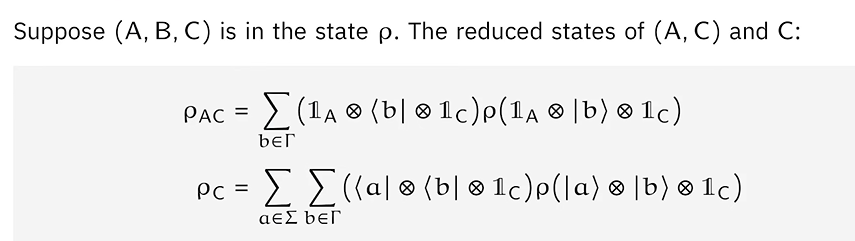

The Identity is applied in the order of system where we want to reduce.

In [72]:
import numpy as np

psi = np.array([[1/np.sqrt(2)],[0],[0],[1/np.sqrt(2)]])
print("psi")
print(psi)

# if you measure b = 0
I_bra0 = np.kron(np.identity(2), np.array([[1],[0]]).T)

print()
print("b=0")
phi_0 = I_bra0.dot(psi)
# equivalent to 1/sqrt(2)
print("pr(b=0) =", np.linalg.norm(phi_0))
print("conditioned state of A")
print(phi_0/np.linalg.norm(phi_0))

# if you measure b = 0
I_bra1 = np.kron(np.identity(2), np.array([[0],[1]]).T)

print()
print("b=1")
phi_1 = I_bra1.dot(psi)
# equivalent to 1/sqrt(2)
print("pr(b=0) =", np.linalg.norm(phi_1))
print("conditioned state of A")
print(phi_1/np.linalg.norm(phi_1))

print()
print("Reduced state of A is by adding the density matrices phi_k")
# equal to I/2
print(phi_0.dot(phi_0.T) + phi_1.dot(phi_1.T))

psi
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

b=0
pr(b=0) = 0.7071067811865475
conditioned state of A
[[1.]
 [0.]]

b=1
pr(b=0) = 0.7071067811865475
conditioned state of A
[[0.]
 [1.]]

Reduced state of A is by adding the density matrices phi_k
[[0.5 0. ]
 [0.  0.5]]


In [80]:
# Using density matrix representation

import numpy as np

psi = np.array([[1/np.sqrt(2)],[0],[0],[1/np.sqrt(2)]])
d_psi = psi.dot(psi.T)
print("psi")
print(psi)
print()
print("density matrix representation of psi")
print(d_psi)

# perform the formula to reduce the state to A
p_A = np.zeros((2,2))
for i in range(2):
    ket_i = np.array([[1] if i == j else [0] for j in range(2)])
    bra_i = ket_i.T
    p_A += np.kron(np.identity(2), bra_i).dot(d_psi.dot(np.kron(np.identity(2), ket_i)))

print()
print("Reduced state of A")
print(p_A)

psi
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

density matrix representation of psi
[[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]

Reduced state of A
[[0.5 0. ]
 [0.  0.5]]


## Partial Trace

This process of reducing a state can be considered as a linear function. 

$$\text{Tr}_B(\rho)=\sum_{b\in\Gamma}(I_A\otimes\bra{b})\rho(I_A\otimes\ket{b}) $$

$\text{Tr}_X(\rho)$ means remove the system $X$ in system $\rho$ to isolate the other system. We say we *trace out* system $X$.

**Equivalent Definition**
$\text{Tr}_A$ and $\text{Tr}_B$ are the unique linear mappings for which these equations are always true:

$$ \text{Tr}_A(M\otimes N) = \text{Tr}(M)N $$

$$ \text{Tr}_B(M\otimes N) = \text{Tr}(N)M $$

This is the reason why it is called the partial trace.

## Example of Partial Trace using the equivalent definition

Consider this state of a pair of qubits $(A,B)$:

$$\rho = \frac{1}{2}\ket{0}\bra{0}\otimes\ket{0}\bra{0} + \frac{1}{2}\ket{1}\bra{1}\otimes\ket{+}\bra{+} $$

Since $Tr$ is a linear function,

$$\rho_A = \text{Tr}_B(\rho) = \text{Tr}\left(\frac{1}{2}\ket{0}\bra{0}\otimes\ket{0}\bra{0}\right)+\text{Tr}\left(\frac{1}{2}\ket{1}\bra{1}\otimes\ket{+}\bra{+}\right)$$

By using the equivalent definition,

$$\rho_A = \text{Tr}_B(\rho) = \text{Tr}(\ket{0}\bra{0})\frac{1}{2}\ket{0}\bra{0}+\text{Tr}(\ket{+}\bra{+})\frac{1}{2}\ket{1}\bra{1}$$

$$\rho_A = \text{Tr}_B(\rho) = \frac{1}{2}\ket{0}\bra{0}+\frac{1}{2}\ket{1}\bra{1}$$

## END